# Single-CNOT syndrome catalog and independent SPSA calibration

Notebook 03 calibrated the first encoding CNOT when its location was known.
We now repeat the experiment for all six CNOT locations in the three-qubit
repetition-code circuit.

This notebook addresses two different questions:

1. **Static identification:** can one fixed syndrome distribution reveal
   which CNOT is faulty?
2. **Active calibration:** if a control coordinate is known, can SPSA perturb
   that coordinate and drive its syndrome loss toward zero?

These questions need not have the same answer.  Several gates can produce
identical syndrome distributions while remaining independently addressable
by the optimizer.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qec_calibration import (  # noqa: E402
    CNOT_GATE_IDS,
    CNOT_LOCATIONS,
    EXPECTED_SINGLE_FAULT_SYNDROMES,
    SYNDROMES,
    calibrate_cnot_parameters_spsa,
    catalog_probability_matrix,
    indistinguishable_signature_groups,
    logical_success_probability,
    normalized_single_fault_response_matrix,
    response_matrix_diagnostics,
    run_parameterized_recovery,
    run_single_fault_catalog,
    theoretical_single_fault_probability_matrix,
)


ANGLE = 0.6
CATALOG_SHOTS = 20_000
OPTIMIZER_SHOTS = 2048
VALIDATION_SHOTS = 8000
RECOVERY_SHOTS = 4096
MAXITER = 20
SEED = 42

## 1. CNOT locations and expected isolated signatures

An isolated target-$R_x$ fault transfers probability from `00` to one
nonzero syndrome.  The transfer probability is

$$
u(\theta)=\sin^2(\theta/2).
$$

In [2]:
location_table = pd.DataFrame(
    {
        "parameter_index": index,
        "gate_id": location.gate_id,
        "stage": location.stage,
        "control": location.control,
        "target": location.target,
        "residual_syndrome": EXPECTED_SINGLE_FAULT_SYNDROMES[
            location.gate_id
        ],
    }
    for index, location in enumerate(CNOT_LOCATIONS)
)
location_table

,parameter_index,gate_id,stage,control,target,residual_syndrome
0,0,enc_01,encoding,data[0],data[1],11
1,1,enc_02,encoding,data[0],data[2],01
2,2,syn_0a,syndrome,data[0],ancilla[0],10
3,3,syn_0b,syndrome,data[1],ancilla[0],10
4,4,syn_1a,syndrome,data[1],ancilla[1],01
5,5,syn_1b,syndrome,data[2],ancilla[1],01


## 2. Sample the six single-fault distributions

Every column below is obtained with exactly one nonzero component of the
six-angle vector.  We compare finite-shot Aer results with the exact
single-fault predictions.

In [3]:
catalog = run_single_fault_catalog(
    ANGLE,
    shots=CATALOG_SHOTS,
    seed=SEED,
)

empirical_matrix = catalog_probability_matrix(catalog)
theory_matrix = theoretical_single_fault_probability_matrix(ANGLE)

catalog_rows = []
for column, signature in enumerate(catalog):
    row = {
        "gate_id": signature.gate_id,
        "expected residual": signature.expected_residual_syndrome,
    }
    for row_index, syndrome in enumerate(SYNDROMES):
        row[f"P({syndrome}) empirical"] = empirical_matrix[row_index, column]
        row[f"P({syndrome}) theory"] = theory_matrix[row_index, column]
    catalog_rows.append(row)

catalog_table = pd.DataFrame(catalog_rows)
catalog_table

,gate_id,expected residual,P(00) empirical,P(00) theory,P(10) empirical,P(10) theory,P(11) empirical,P(11) theory,P(01) empirical,P(01) theory
0,enc_01,11,0.91415,0.912668,0.0000,0.000000,0.08585,0.087332,0.00000,0.000000
1,enc_02,01,0.91195,0.912668,0.0000,0.000000,0.00000,0.000000,0.08805,0.087332
2,syn_0a,10,0.91220,0.912668,0.0878,0.087332,0.00000,0.000000,0.00000,0.000000
3,syn_0b,10,0.91390,0.912668,0.0861,0.087332,0.00000,0.000000,0.00000,0.000000
4,syn_1a,01,0.91305,0.912668,0.0000,0.000000,0.00000,0.000000,0.08695,0.087332
5,syn_1b,01,0.91260,0.912668,0.0000,0.000000,0.00000,0.000000,0.08740,0.087332


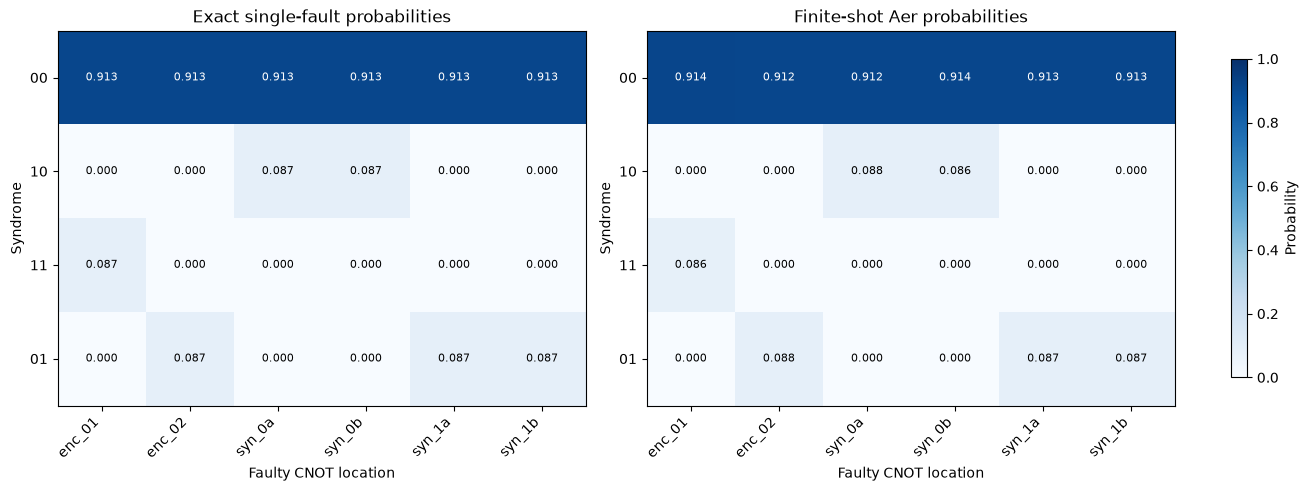

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for ax, matrix, title in (
    (axes[0], theory_matrix, "Exact single-fault probabilities"),
    (axes[1], empirical_matrix, "Finite-shot Aer probabilities"),
):
    image = ax.imshow(matrix, vmin=0.0, vmax=1.0, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(CNOT_GATE_IDS)), CNOT_GATE_IDS, rotation=45, ha="right")
    ax.set_yticks(range(len(SYNDROMES)), SYNDROMES)
    ax.set_xlabel("Faulty CNOT location")
    ax.set_ylabel("Syndrome")
    ax.set_title(title)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(
                column,
                row,
                f"{matrix[row, column]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if matrix[row, column] > 0.55 else "black",
            )

fig.colorbar(image, ax=axes, label="Probability", shrink=0.85)
plt.show()

## 3. Build the normalized syndrome-response matrix

At the ideal point, the derivative with respect to the physical angle
vanishes:

$$
\left.\frac{\partial}{\partial\theta}
\sin^2(\theta/2)\right|_{\theta=0}=0.
$$

We therefore use $u=\sin^2(\theta/2)$ as the local fault-strength variable.
Subtracting the ideal vector $(1,0,0,0)^T$ and dividing by $u$ gives the
angle-independent response matrix

$$
R_{s,g}=\frac{P(s\mid\theta_g)-P(s\mid\mathbf 0)}
{\sin^2(\theta_g/2)}.
$$

In [5]:
response_matrix = normalized_single_fault_response_matrix(ANGLE)
diagnostics = response_matrix_diagnostics(response_matrix)
signature_groups = indistinguishable_signature_groups(response_matrix)

response_table = pd.DataFrame(
    response_matrix,
    index=[f"delta P({syndrome}) / u" for syndrome in SYNDROMES],
    columns=CNOT_GATE_IDS,
)
response_table

,enc_01,enc_02,syn_0a,syn_0b,syn_1a,syn_1b
delta P(00) / u,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
delta P(10) / u,0.0,0.0,1.0,1.0,0.0,0.0
delta P(11) / u,1.0,0.0,0.0,0.0,0.0,0.0
delta P(01) / u,0.0,1.0,0.0,0.0,1.0,1.0


In [6]:
print("Response-matrix rank:", diagnostics.rank)
print("Singular values:", np.round(diagnostics.singular_values, 6))
print(
    "Condition number on the nonzero row space:",
    f"{diagnostics.nonzero_condition_number:.6f}",
)
print("\nIndistinguishable static-signature groups:")
for group in signature_groups:
    print("  ", group)

Response-matrix rank: 3
Singular values: [2.901522 1.544918 1.092885 0.      ]
Condition number on the nonzero row space: 2.654921

Indistinguishable static-signature groups:
   ('enc_01',)
   ('enc_02', 'syn_1a', 'syn_1b')
   ('syn_0a', 'syn_0b')


There are four measured outcomes but only three independent probabilities,
because they sum to one.  The response matrix has rank three and separates
only three signature classes:

- `enc_01`;
- `syn_0a`, `syn_0b`;
- `enc_02`, `syn_1a`, `syn_1b`.

A single passive distribution therefore cannot identify all six gate
locations.

## 4. Calibrate every gate independently with SPSA

Static degeneracy does not prevent active single-coordinate calibration.
For each experiment we tell SPSA which gate-control coordinate it is allowed
to perturb, while every other coordinate remains zero.

In [7]:
single_gate_results = {}
calibration_rows = []

for offset, gate_id in enumerate(CNOT_GATE_IDS):
    result = calibrate_cnot_parameters_spsa(
        initial_angles={gate_id: ANGLE},
        active_gate_ids=(gate_id,),
        maxiter=MAXITER,
        shots_per_evaluation=OPTIMIZER_SHOTS,
        validation_shots=VALIDATION_SHOTS,
        learning_rate=1.2,
        perturbation=0.12,
        seed=SEED + 100 + offset,
    )
    single_gate_results[gate_id] = result
    calibration_rows.append(
        {
            "gate_id": gate_id,
            "signature": EXPECTED_SINGLE_FAULT_SYNDROMES[gate_id],
            "initial_angle": result.initial_angles[gate_id],
            "optimized_angle": result.optimized_angles[gate_id],
            "initial_loss": result.initial_loss,
            "final_loss": result.validation_loss,
            "function_evaluations": result.function_evaluations,
        }
    )

calibration_table = pd.DataFrame(calibration_rows)
calibration_table

,gate_id,signature,initial_angle,optimized_angle,initial_loss,final_loss,function_evaluations
0,enc_01,11,0.6,0.006738,0.090750,0.000000,60
1,enc_02,01,0.6,-0.000586,0.085875,0.000000,60
2,syn_0a,10,0.6,0.009180,0.090500,0.000000,60
3,syn_0b,10,0.6,0.001855,0.094000,0.000000,60
4,syn_1a,01,0.6,0.001855,0.084500,0.000000,60
5,syn_1b,01,0.6,0.004297,0.083750,0.000125,60


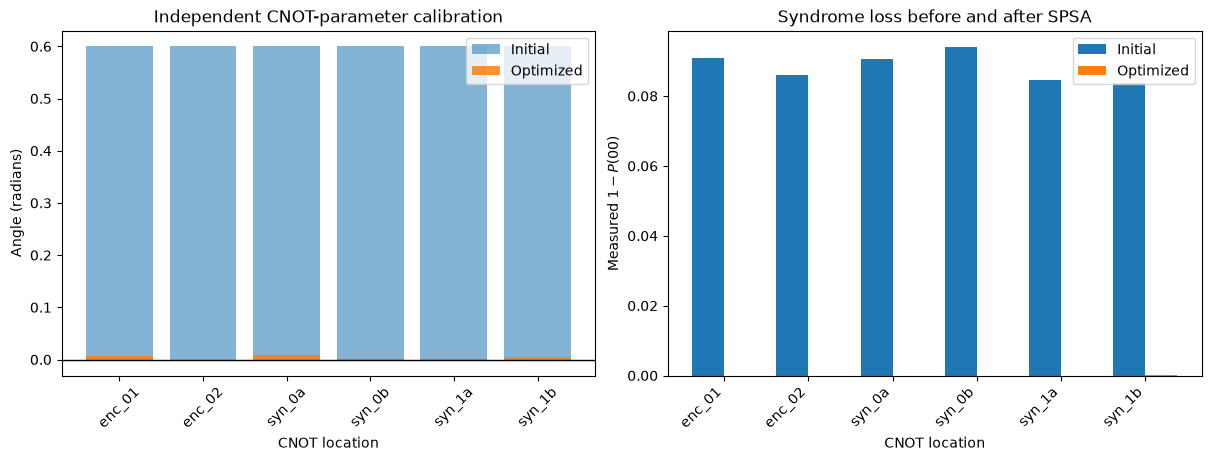

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].bar(
    calibration_table["gate_id"],
    calibration_table["initial_angle"],
    alpha=0.55,
    label="Initial",
)
axes[0].bar(
    calibration_table["gate_id"],
    calibration_table["optimized_angle"],
    alpha=0.85,
    label="Optimized",
)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set(
    xlabel="CNOT location",
    ylabel="Angle (radians)",
    title="Independent CNOT-parameter calibration",
)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

x = np.arange(len(calibration_table))
width = 0.38
axes[1].bar(
    x - width / 2,
    calibration_table["initial_loss"],
    width,
    label="Initial",
)
axes[1].bar(
    x + width / 2,
    calibration_table["final_loss"],
    width,
    label="Optimized",
)
axes[1].set_xticks(x, calibration_table["gate_id"], rotation=45, ha="right")
axes[1].set(
    xlabel="CNOT location",
    ylabel=r"Measured $1-P(00)$",
    title="Syndrome loss before and after SPSA",
)
axes[1].legend()

plt.show()

## 5. Demonstrate the sign ambiguity

A fixed syndrome distribution is even in the angle,

$$P(s\mid+\theta)=P(s\mid-\theta),$$

so it does not identify the sign.  SPSA nevertheless learns a descent
direction by comparing controlled positive and negative perturbations.

In [9]:
sign_rows = []
sign_results = {}

for offset, initial_angle in enumerate((+ANGLE, -ANGLE)):
    result = calibrate_cnot_parameters_spsa(
        initial_angles={"enc_01": initial_angle},
        active_gate_ids=("enc_01",),
        maxiter=MAXITER,
        shots_per_evaluation=OPTIMIZER_SHOTS,
        validation_shots=VALIDATION_SHOTS,
        learning_rate=1.2,
        perturbation=0.12,
        seed=SEED + 300 + offset,
    )
    sign_results[initial_angle] = result
    sign_rows.append(
        {
            "initial_angle": initial_angle,
            "optimized_angle": result.optimized_angles["enc_01"],
            "initial_loss": result.initial_loss,
            "final_loss": result.validation_loss,
        }
    )

pd.DataFrame(sign_rows)

,initial_angle,optimized_angle,initial_loss,final_loss
0,0.6,0.001855,0.090000,0.0
1,-0.6,-0.009180,0.086875,0.0


## 6. Validate active recovery across physical-error probes

For every faulty CNOT, we compare the mean logical success probability over
the four probe settings `None`, $X_0$, $X_1$, and $X_2$.  Logical zero is
sufficient here because this bit-flip experiment is symmetric on the two
logical computational-basis codewords.

In [10]:
recovery_rows = []

for gate_offset, gate_id in enumerate(CNOT_GATE_IDS):
    result = single_gate_results[gate_id]
    for probe_offset, error_qubit in enumerate((None, 0, 1, 2)):
        counts_before = run_parameterized_recovery(
            result.initial_angles,
            error_qubit=error_qubit,
            logical_value=0,
            shots=RECOVERY_SHOTS,
            seed=SEED + 1000 + 10 * gate_offset + probe_offset,
        )
        counts_after = run_parameterized_recovery(
            result.optimized_angles,
            error_qubit=error_qubit,
            logical_value=0,
            shots=RECOVERY_SHOTS,
            seed=SEED + 2000 + 10 * gate_offset + probe_offset,
        )
        recovery_rows.append(
            {
                "gate_id": gate_id,
                "physical_error": "None" if error_qubit is None else f"X{error_qubit}",
                "success_before": logical_success_probability(counts_before, 0),
                "success_after": logical_success_probability(counts_after, 0),
            }
        )

recovery_table = pd.DataFrame(recovery_rows)
recovery_summary = (
    recovery_table.groupby("gate_id", sort=False)[
        ["success_before", "success_after"]
    ]
    .mean()
    .reset_index()
)
recovery_summary

,gate_id,success_before,success_after
0,enc_01,0.956360,1.000000
1,enc_02,0.957947,1.000000
2,syn_0a,0.912598,1.000000
3,syn_0b,0.912354,1.000000
4,syn_1a,0.916016,1.000000
5,syn_1b,0.915894,0.999878


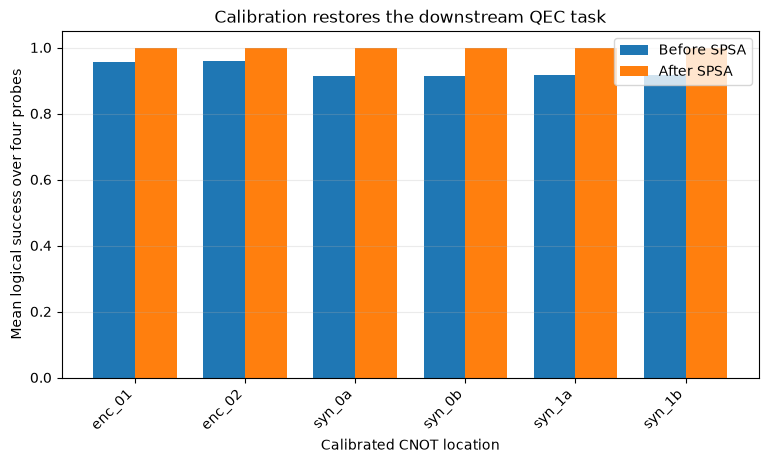

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(recovery_summary))
width = 0.38
ax.bar(
    x - width / 2,
    recovery_summary["success_before"],
    width,
    label="Before SPSA",
)
ax.bar(
    x + width / 2,
    recovery_summary["success_after"],
    width,
    label="After SPSA",
)
ax.set_xticks(x, recovery_summary["gate_id"], rotation=45, ha="right")
ax.set(
    ylabel="Mean logical success over four probes",
    xlabel="Calibrated CNOT location",
    title="Calibration restores the downstream QEC task",
    ylim=(0.0, 1.05),
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()

## 7. Reproducible checks

In [12]:
assert diagnostics.rank == 3
assert signature_groups == (
    ("enc_01",),
    ("enc_02", "syn_1a", "syn_1b"),
    ("syn_0a", "syn_0b"),
)
assert np.max(np.abs(empirical_matrix - theory_matrix)) < 0.03
assert (calibration_table["final_loss"] < calibration_table["initial_loss"]).all()
assert (calibration_table["optimized_angle"].abs() < 0.05).all()
assert all(abs(row["optimized_angle"]) < 0.05 for row in sign_rows)
assert (
    recovery_summary["success_after"]
    >= recovery_summary["success_before"] - 0.01
).all()

print("Six-gate single-fault catalog: PASS")
print("Independent SPSA calibration: PASS")
print("Static response rank:", diagnostics.rank, "of", len(CNOT_GATE_IDS))

Six-gate single-fault catalog: PASS
Independent SPSA calibration: PASS
Static response rank: 3 of 6


## Conclusion

All six CNOT controls can be calibrated independently when the active
coordinate is known.  Nevertheless, their passive syndrome signatures span
only three independent response directions.  Notebook 05 next activates
several coordinates simultaneously and tests whether low syndrome loss also
implies recovery of the individual calibration parameters.